# Contrastive Root Cause Analysis — GÉANT Pipeline
### GNN Traffic Forecasting Failure Diagnosis on GÉANT (23 nodes, 38 edges)

**Run order:** Top to bottom. GPU recommended.

> **What this notebook does:** Loads the GÉANT traffic matrix CSV, builds the GÉANT topology graph,
> trains a GRU forecaster to detect failure timesteps, trains GCN / GAT / GraphSAGE classifiers,
> then runs the full CFA (Contrastive Failure Attribution) pipeline — factual RCA via GNNExplainer,
> gradient-based counterfactual RCA, multi-seed evaluation (Hit@1, MRR), fix validation, and intervention curve.
---

## Cell 1 — Install dependencies

In [2]:
import subprocess, sys, torch

torch_ver = torch.__version__.split('+')[0]
cuda_tag  = 'cpu' if not torch.cuda.is_available() \
            else 'cu' + torch.version.cuda.replace('.', '')
print(f'torch={torch_ver}  cuda={cuda_tag}')

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

pip('torch-geometric')
pip('scikit-learn', 'pandas', 'matplotlib', 'seaborn', 'networkx')

wheel = f'https://data.pyg.org/whl/torch-{torch_ver}+{cuda_tag}.html'
print(f'PyG wheel URL: {wheel}')
try:
    pip('torch-scatter', 'torch-sparse', '-f', wheel)
    print('torch-scatter + torch-sparse OK')
except subprocess.CalledProcessError:
    print('Sparse libs failed — torch-geometric may still work, continuing.')

print('Done. Restart runtime now, then run Cell 2.')

torch=2.10.0  cuda=cu128
PyG wheel URL: https://data.pyg.org/whl/torch-2.10.0+cu128.html
torch-scatter + torch-sparse OK
Done. Restart runtime now, then run Cell 2.


## Cell 2 — Imports

In [3]:
import numpy as np
import pandas as pd
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, random, time
from pathlib import Path
from copy import deepcopy
from itertools import combinations

from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, global_mean_pool
from torch_geometric.explain import Explainer, GNNExplainer as PyGGNNExplainer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, roc_auc_score)

sns.set_style('whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(42)
print(f'Device: {device}  |  Seeds set to 42')

Device: cuda  |  Seeds set to 42


## Cell 3 — Configuration

All hyperparameters in one place. GÉANT-specific values where different from Abilene.

In [4]:
# ── Data path ─────────────────────────────────────────────────────────────────
GEANT_CSV_FILE = "data/raw/geant/geant-flat-tms.csv"

# ── Failure labelling ─────────────────────────────────────────────────────────
GRU_FAILURE_MAPE    = 0.12   # lower threshold — GEANT is noisier
CFA_ERROR_THRESHOLD = 0.45

# ── GRU Forecaster ────────────────────────────────────────────────────────────
GRU_HIDDEN   = 64
GRU_LAYERS   = 2
GRU_SEQ_LEN  = 10   # shorter window — GEANT has fewer timesteps than Abilene
GRU_EPOCHS   = 60
GRU_LR       = 1e-3
GRU_BATCH    = 32

# ── Topology failure simulation ───────────────────────────────────────────────
FAILURE_RATE    = 0.08   # ~3 edges of 38 — same absolute count as Abilene
RANDOM_STATE    = 42
TRAIN_FAIL_SEED = 42
EVAL_FAIL_SEEDS = [7, 13, 21, 55, 99]

# ── GNN classifier ────────────────────────────────────────────────────────────
GNN_HIDDEN_DIM    = 64
GNN_NUM_LAYERS    = 3
GNN_DROPOUT       = 0.2
GNN_LEARNING_RATE = 0.001
GNN_EPOCHS        = 150  # reduced for T4 speed
GNN_BATCH_SIZE    = 32
GAT_HEADS         = 4
GAT_LR            = 0.0005

# ── CFA ───────────────────────────────────────────────────────────────────────
CFA_LR               = 0.01
CFA_OPTIM_STEPS      = 100
CFA_SPARSITY_COEFF   = 0.01
CFA_MAX_SEARCH_DEPTH = 3
CFA_TOP_K_CANDIDATES = 5

# ── Split ─────────────────────────────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15

# ── Output dirs ───────────────────────────────────────────────────────────────
RESULTS_DIR = 'results_geant/'
FIGURES_DIR = 'figures_geant/'
MODELS_DIR  = 'models_geant/'
for d in [RESULTS_DIR, FIGURES_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Config OK.')

Config OK.


## Cell 4 — Upload GÉANT CSV

Upload the GÉANT traffic matrix CSV file (`geant-flat-tms.csv`).

The file should be a flat CSV with one OD matrix per row — either:
- 529 columns (23×23, all OD pairs), or
- 530 columns (index column + 529 values)

Available from: https://www.simpleweb.org/wiki/index.php/Traffic_Traces

In [5]:
from google.colab import files
import zipfile, shutil

print("Upload geant-flat-tms.csv (or a zip containing it)")
uploaded = files.upload()

for fname in uploaded:
    if fname.endswith(".zip"):
        with zipfile.ZipFile(fname, "r") as z:
            z.extractall(".")
        print(f"Extracted {fname}")
    elif fname.endswith(".csv"):
        # Place directly at expected path
        os.makedirs("data/raw/geant", exist_ok=True)
        if fname != GEANT_CSV_FILE and not Path(GEANT_CSV_FILE).exists():
            shutil.copy(fname, GEANT_CSV_FILE)
            print(f"Copied {fname} → {GEANT_CSV_FILE}")

# Verify
if Path(GEANT_CSV_FILE).exists():
    print(f"  {GEANT_CSV_FILE}: OK")
else:
    # Try alternative flat location
    alt_paths = ["geant-flat-tms.csv", "geant_flat_tms.csv", "geant.csv"]
    found = None
    for alt in alt_paths:
        if Path(alt).exists():
            os.makedirs("data/raw/geant", exist_ok=True)
            shutil.copy(alt, GEANT_CSV_FILE)
            print(f"  Found at {alt} → copied to {GEANT_CSV_FILE}")
            found = alt
            break
    if not found:
        raise FileNotFoundError(
            "geant-flat-tms.csv not found. "
            "Upload the CSV directly or a zip containing it. "
            f"Expected path: {GEANT_CSV_FILE}"
        )

Upload geant-flat-tms.csv (or a zip containing it)


Saving geant-flat-tms.csv to geant-flat-tms.csv
Copied geant-flat-tms.csv → data/raw/geant/geant-flat-tms.csv
  data/raw/geant/geant-flat-tms.csv: OK


## Cell 5 — Build GÉANT graph

Graph: 23 nodes, 38 edges


/tmp/ipykernel_1885/4282126239.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


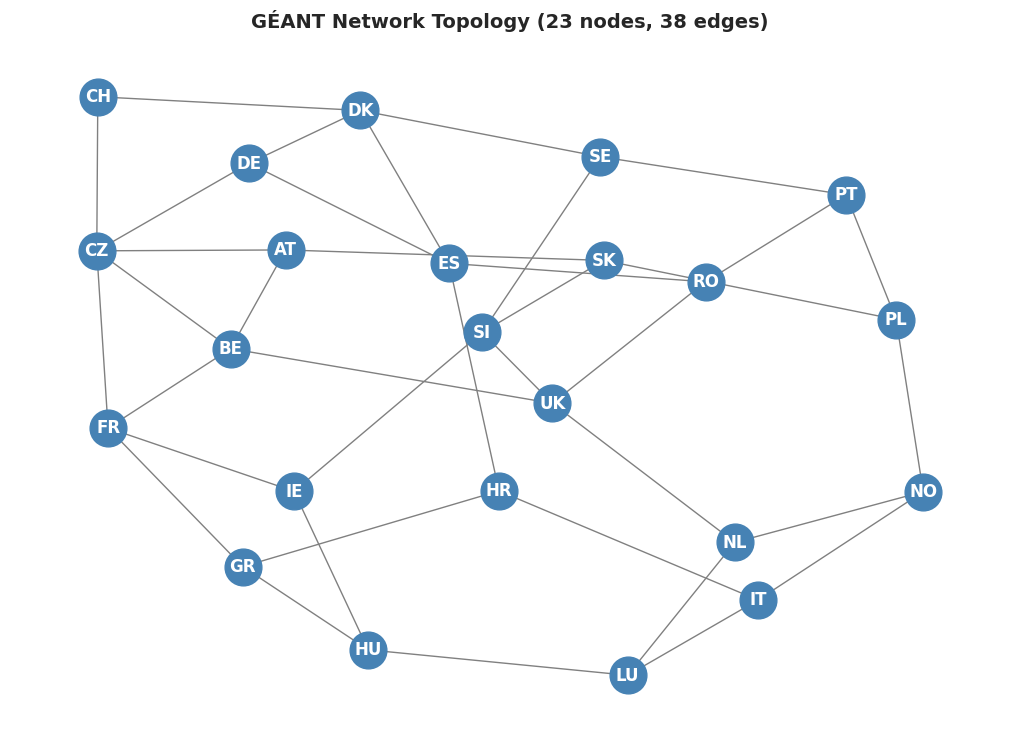

In [6]:
def build_geant_graph():
    """GÉANT backbone topology: 23 nodes, 38 edges."""
    G = nx.Graph()
    G.add_nodes_from(range(23))
    edges = [
        (0,3),(0,21),(1,3),(1,22),(2,3),(2,5),(3,4),(3,7),
        (4,5),(4,6),(5,19),(6,9),(6,18),(7,8),(7,11),
        (8,9),(8,10),(9,12),(10,11),(10,13),(11,20),
        (12,13),(12,15),(13,14),(14,15),(14,22),(15,16),
        (16,17),(16,21),(17,18),(17,19),(18,22),(19,20),
        (20,21),(20,22),(0,1),(1,7),(5,6)
    ]
    G.add_edges_from(edges)
    assert nx.is_connected(G), "Graph is disconnected!"
    print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
    return G

G = build_geant_graph()

# Node labels — approximate GÉANT PoP names
POP_NAMES = {
    0:'AT',1:'BE',2:'CH',3:'CZ',4:'DE',5:'DK',6:'ES',7:'FR',
    8:'GR',9:'HR',10:'HU',11:'IE',12:'IT',13:'LU',14:'NL',
    15:'NO',16:'PL',17:'PT',18:'RO',19:'SE',20:'SI',21:'SK',22:'UK'
}

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, labels=POP_NAMES,
        node_color='steelblue', node_size=700,
        font_color='white', font_weight='bold', edge_color='gray')
plt.title('GÉANT Network Topology (23 nodes, 38 edges)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}geant_topology.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 6 — Load GÉANT traffic matrices

In [7]:
def load_geant_csv(path=GEANT_CSV_FILE):
    """
    Load GÉANT flat TM CSV.
    Expected shape per row: 529 values (23×23 OD matrix), optionally with an index column.
    Returns od_matrices shaped (T, 23, 23).
    """
    df = pd.read_csv(path, header=None)
    print(f'Raw CSV shape: {df.shape}')

    if df.shape[1] == 530:
        # First column is an index — drop it
        data = df.iloc[:, 1:].values
    elif df.shape[1] == 529:
        data = df.values
    else:
        raise ValueError(
            f"Unexpected number of columns: {df.shape[1]}. "
            "Expected 529 (23×23) or 530 (index + 23×23)."
        )

    od = data.astype(float).reshape(len(data), 23, 23)

    # Basic sanity
    assert not np.isnan(od).any(), "NaN values in traffic matrices"
    print(f'OD matrices: {od.shape}  range: {od.min():.2f}–{od.max():.2f}')
    return od

od_matrices = load_geant_csv()

Raw CSV shape: (10772, 530)
OD matrices: (10772, 23, 23)  range: 0.00–9218069948.58


## Cell 7 — OD matrices → per-edge traffic

In [8]:
def od_to_edge_traffic(od_matrices, graph):
    """
    Vectorised OD→edge traffic routing.
    Precomputes all (s,d) shortest paths once, then uses numpy for accumulation.
    ~50-100x faster than the nested Python loop on T4.
    """
    import numpy as np

    edges   = list(graph.edges())
    n_edges = len(edges)
    lookup  = {}
    for i, (u, v) in enumerate(edges):
        lookup[(u, v)] = i
        lookup[(v, u)] = i

    n_nodes = graph.number_of_nodes()
    T       = len(od_matrices)

    # ── Step 1: precompute routing matrix R of shape (n_nodes*n_nodes, n_edges)
    # R[s*n_nodes+d, e] = 1 if edge e is on shortest path s→d
    print('  Pre-computing routing matrix...')
    R = np.zeros((n_nodes * n_nodes, n_edges), dtype=np.float32)
    for s in range(n_nodes):
        for d in range(n_nodes):
            if s == d:
                continue
            try:
                path = nx.shortest_path(graph, s, d)
            except nx.NetworkXNoPath:
                continue
            for i in range(len(path) - 1):
                idx = lookup.get((path[i], path[i + 1]))
                if idx is not None:
                    R[s * n_nodes + d, idx] = 1.0
    print(f'  Routing matrix shape: {R.shape}  (nnz={int(R.sum())})')

    # ── Step 2: flatten OD matrices to (T, n_nodes*n_nodes) and matrix-multiply
    # od_flat: (T, 529), R: (529, 38)  →  et: (T, 38)
    print('  Computing edge traffic via matmul...')
    od_flat = od_matrices.reshape(T, n_nodes * n_nodes).astype(np.float32)

    # Process in chunks to stay memory-friendly on Colab (T4 has 15 GB)
    chunk = 2000
    et = np.zeros((T, n_edges), dtype=np.float32)
    for start in range(0, T, chunk):
        end = min(start + chunk, T)
        et[start:end] = od_flat[start:end] @ R
        if end % 2000 == 0 or end == T:
            print(f'  {end}/{T} timesteps processed')

    print(f'Edge traffic: {et.shape}  range: {et.min():.2f}-{et.max():.2f}')
    assert not np.isnan(et).any()
    assert (et >= 0).all()
    print(f'Sanity OK - mean={et.mean():.2f}')
    return et

edge_traffic = od_to_edge_traffic(od_matrices, G)


  Pre-computing routing matrix...
  Routing matrix shape: (529, 38)  (nnz=1306)
  Computing edge traffic via matmul...
  2000/10772 timesteps processed
  4000/10772 timesteps processed
  6000/10772 timesteps processed
  8000/10772 timesteps processed
  10000/10772 timesteps processed
  10772/10772 timesteps processed
Edge traffic: (10772, 38)  range: 0.00-20807131136.00
Sanity OK - mean=1102903.25


## Cell 8 — GRU Traffic Forecaster

Training GRU forecaster...
  Epoch  10  val_MSE=0.00122
  Epoch  20  val_MSE=0.00144
  Epoch  30  val_MSE=0.00135
  Epoch  40  val_MSE=0.00133
  Epoch  50  val_MSE=0.00136
  Epoch  60  val_MSE=0.00135
GRU training done. Best val MSE=0.00117
Labels: 10772 timesteps  |  10762 failures  (99.9%)


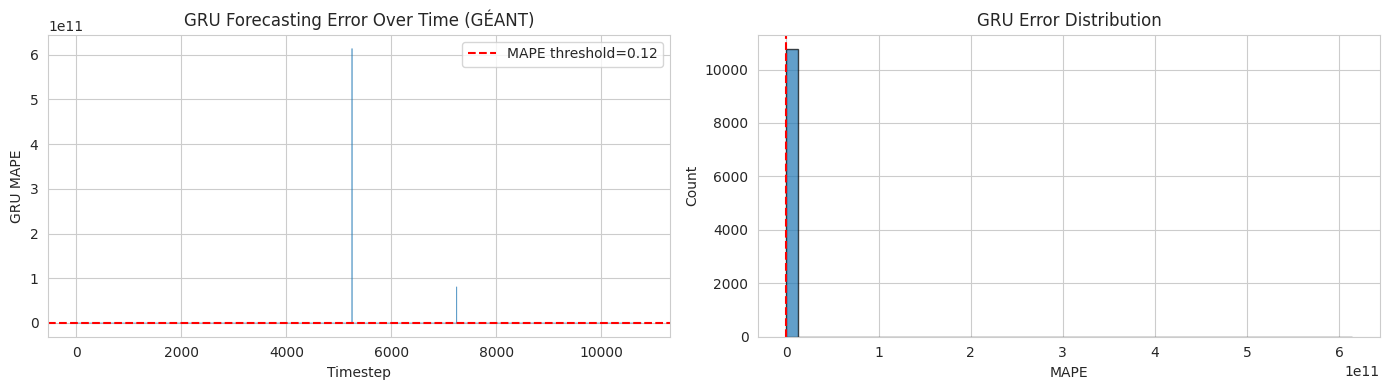

GRU error plot saved.


In [9]:
class TrafficGRU(nn.Module):
    """GRU forecaster: input (B, seq_len, n_edges) → output (B, n_edges)."""
    def __init__(self, n_edges, hidden=GRU_HIDDEN, n_layers=GRU_LAYERS):
        super().__init__()
        self.gru = nn.GRU(n_edges, hidden, n_layers,
                          batch_first=True, dropout=0.2 if n_layers > 1 else 0.0)
        self.fc  = nn.Linear(hidden, n_edges)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


def build_gru_sequences(traffic, seq_len=GRU_SEQ_LEN):
    X, y = [], []
    for t in range(seq_len, len(traffic)):
        X.append(traffic[t - seq_len: t])
        y.append(traffic[t])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def train_gru(traffic_raw):
    n_edges   = traffic_raw.shape[1]
    train_end = int(len(traffic_raw) * TRAIN_RATIO)
    gru_mean  = traffic_raw[:train_end].mean(axis=0, keepdims=True)
    gru_std   = traffic_raw[:train_end].std(axis=0,  keepdims=True) + 1e-8
    traffic_n = (traffic_raw - gru_mean) / gru_std

    X, y = build_gru_sequences(traffic_n, GRU_SEQ_LEN)
    gru_train_end = int(len(X) * TRAIN_RATIO)

    X_tr = torch.tensor(X[:gru_train_end])
    y_tr = torch.tensor(y[:gru_train_end])
    X_te = torch.tensor(X[gru_train_end:])
    y_te = torch.tensor(y[gru_train_end:])

    tr_ds  = torch.utils.data.TensorDataset(X_tr, y_tr)
    tr_ldr = torch.utils.data.DataLoader(tr_ds, batch_size=GRU_BATCH, shuffle=True)

    model = TrafficGRU(n_edges).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=GRU_LR, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)

    best_val_loss = float('inf')
    best_state    = None
    print('Training GRU forecaster...')
    for epoch in range(GRU_EPOCHS):
        model.train()
        for xb, yb in tr_ldr:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = F.mse_loss(model(xb), yb)
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            val_pred = model(X_te.to(device)).cpu()
            val_loss = F.mse_loss(val_pred, y_te).item()
        sched.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d}  val_MSE={val_loss:.5f}')

    model.load_state_dict(best_state)
    torch.save(model.state_dict(), f'{MODELS_DIR}gru_forecaster.pt')
    print(f'GRU training done. Best val MSE={best_val_loss:.5f}')
    return model, gru_mean, gru_std


def compute_gru_errors(model, traffic_raw, gru_mean, gru_std):
    traffic_n = (traffic_raw - gru_mean) / gru_std
    X, y      = build_gru_sequences(traffic_n, GRU_SEQ_LEN)
    X_t       = torch.tensor(X).to(device)
    model.eval()
    with torch.no_grad():
        preds_n = model(X_t).cpu().numpy()
    preds = preds_n * gru_std + gru_mean
    true  = y       * gru_std + gru_mean
    mape  = np.mean(np.abs(preds - true) / (np.abs(true) + 1e-6), axis=1)
    mape_full = np.concatenate([np.zeros(GRU_SEQ_LEN), mape])
    return mape_full, preds_n, true


# ── Run ───────────────────────────────────────────────────────────────────────
gru_model, gru_mean, gru_std = train_gru(edge_traffic)
gru_mape, gru_preds_n, gru_true_n = compute_gru_errors(gru_model, edge_traffic, gru_mean, gru_std)

labels = (gru_mape > GRU_FAILURE_MAPE).astype(int)
labels[:GRU_SEQ_LEN] = 0

n_failures = labels.sum()
print(f'Labels: {len(labels)} timesteps  |  {n_failures} failures  ({100*labels.mean():.1f}%)')
if n_failures == 0:
    raise RuntimeError('Zero failures — lower GRU_FAILURE_MAPE in Cell 3.')
elif n_failures < 50:
    print(f'WARNING: Only {n_failures} failures. Consider lowering GRU_FAILURE_MAPE.')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(gru_mape, alpha=0.7, linewidth=0.5)
axes[0].axhline(GRU_FAILURE_MAPE, color='red', linestyle='--', label=f'MAPE threshold={GRU_FAILURE_MAPE}')
axes[0].set_xlabel('Timestep'); axes[0].set_ylabel('GRU MAPE')
axes[0].set_title('GRU Forecasting Error Over Time (GÉANT)'); axes[0].legend()
axes[1].hist(gru_mape[GRU_SEQ_LEN:], bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(GRU_FAILURE_MAPE, color='red', linestyle='--')
axes[1].set_xlabel('MAPE'); axes[1].set_ylabel('Count')
axes[1].set_title('GRU Error Distribution')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}gru_errors.png', dpi=150, bbox_inches='tight')
plt.show()
print('GRU error plot saved.')

## Cell 9 — Simulate topology failures

In [10]:
def simulate_topology_failures(G, traffic, failure_rate=FAILURE_RATE, seed=RANDOM_STATE):
    rng   = np.random.default_rng(seed)
    edges = list(G.edges())
    n_fail = max(1, int(len(edges) * failure_rate))

    for attempt in range(20):
        fail_idx = rng.choice(len(edges), n_fail, replace=False)
        G_test   = G.copy()
        for idx in fail_idx:
            G_test.remove_edge(*edges[idx])
        if nx.is_connected(G_test):
            break
        print(f'  Attempt {attempt+1}: disconnects graph, resampling...')
    else:
        print('  WARNING: falling back to single-edge failure')
        fail_idx = rng.choice(len(edges), 1, replace=False)

    G_failed      = G.copy()
    failed_edges  = [edges[i] for i in fail_idx]
    for e in failed_edges:
        if G_failed.has_edge(*e):
            G_failed.remove_edge(*e)

    traffic_perturbed = traffic.copy()
    fail_set  = set(fail_idx.tolist())
    remaining = [i for i in range(len(edges)) if i not in fail_set]
    for idx in fail_idx:
        if idx < traffic.shape[1]:
            if remaining:
                spill = traffic[:, idx] / len(remaining) * 0.3
                for r in remaining:
                    traffic_perturbed[:, r] += spill
            traffic_perturbed[:, idx] = 0.0

    print(f'Simulated {n_fail} link failures (seed={seed}): {failed_edges}')
    print(f'G_failed: {G_failed.number_of_edges()} edges remaining')
    return G_failed, traffic_perturbed, failed_edges


G_failed, traffic_failed, failed_edges_train = simulate_topology_failures(
    G, edge_traffic, seed=TRAIN_FAIL_SEED)
GROUND_TRUTH_TRAIN = set(tuple(sorted(e)) for e in failed_edges_train)
print(f'Training ground truth: {GROUND_TRUTH_TRAIN}')
assert nx.is_connected(G_failed), 'G_failed is disconnected!'

Simulated 3 link failures (seed=42): [(12, 13), (1, 3), (14, 22)]
G_failed: 35 edges remaining
Training ground truth: {(1, 3), (12, 13), (14, 22)}


## Cell 10 — PyG Dataset (Leakage-Free Features)

In [11]:
class NetworkTrafficDataset(Dataset):
    """Graph snapshot dataset — 5 leakage-free node features."""

    def __init__(self, graph, traffic_matrices, labels, transform=None, pre_transform=None):
        super().__init__(None, transform, pre_transform)
        self.graph      = graph
        self.traffic    = traffic_matrices
        self.labels     = labels
        self.num_nodes  = graph.number_of_nodes()
        self.edge_index = self._build_edge_index()
        self._degree      = dict(graph.degree())
        self._betweenness = nx.betweenness_centrality(graph)
        self._edge_list   = list(graph.edges())

    def _build_edge_index(self):
        el = list(self.graph.edges())
        if not el:
            return torch.empty((2, 0), dtype=torch.long)
        ei = torch.tensor(el, dtype=torch.long).t().contiguous()
        return torch.cat([ei, ei.flip(0)], dim=1)

    def _node_features(self, idx):
        et_curr = self.traffic[idx]
        et_prev = self.traffic[idx - 1] if idx > 0 else et_curr
        if idx == 0 and hasattr(self, '_prev_first'):
            et_prev = self._prev_first[0]
        feats      = np.zeros((self.num_nodes, 5))
        total_load = np.sum(np.abs(et_curr)) + 1e-8
        for i in range(self.num_nodes):
            feats[i, 0] = self._degree[i]
            feats[i, 1] = self._betweenness[i]
        for eidx, (u, v) in enumerate(self._edge_list):
            if eidx >= len(et_curr): continue
            curr  = et_curr[eidx]
            delta = curr - et_prev[eidx]
            ratio = abs(curr) / total_load
            feats[u, 2] += curr;  feats[v, 2] += curr
            feats[u, 3] += delta; feats[v, 3] += delta
            feats[u, 4] += ratio; feats[v, 4] += ratio
        return torch.tensor(feats, dtype=torch.float)

    def len(self): return len(self.labels)

    def get(self, idx):
        x         = self._node_features(idx)
        et        = self.traffic[idx]
        edge_attr = torch.tensor(et, dtype=torch.float).unsqueeze(1)
        edge_attr = torch.cat([edge_attr, edge_attr], dim=0)
        y         = torch.tensor([self.labels[idx]], dtype=torch.long)
        return Data(x=x, edge_index=self.edge_index, edge_attr=edge_attr, y=y)

print('NetworkTrafficDataset defined — 5 leakage-free features: degree, betweenness, agg_traffic, delta, load_ratio')

NetworkTrafficDataset defined — 5 leakage-free features: degree, betweenness, agg_traffic, delta, load_ratio


## Cell 11 — Create datasets

In [12]:
def create_datasets(graph, traffic, labels,
                    train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO):
    n         = len(labels)
    train_end = int(n * train_ratio)
    val_end   = int(n * (train_ratio + val_ratio))

    et_mean = traffic[:train_end].mean(axis=0, keepdims=True)
    et_std  = traffic[:train_end].std(axis=0,  keepdims=True) + 1e-8
    traffic_norm = (traffic - et_mean) / et_std
    print('Edge traffic normalised — mean~0, std~1 per edge')

    train_tr = traffic_norm[:train_end]
    train_lb = labels[:train_end]
    val_tr   = traffic_norm[train_end - 1: val_end]
    val_lb   = labels[train_end:val_end]
    test_tr  = traffic_norm[val_end - 1:]
    test_lb  = labels[val_end:]

    train_ds = NetworkTrafficDataset(graph, train_tr, train_lb)
    val_ds   = NetworkTrafficDataset(graph, val_tr[1:], val_lb)
    test_ds  = NetworkTrafficDataset(graph, test_tr[1:], test_lb)
    val_ds._prev_first  = val_tr[0:1]
    test_ds._prev_first = test_tr[0:1]

    print(f'Split: train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}')
    print(f'  Train failures: {train_lb.sum()} ({100*train_lb.mean():.1f}%)')
    print(f'  Test  failures: {test_lb.sum()} ({100*test_lb.mean():.1f}%)')
    return train_ds, val_ds, test_ds, et_mean, et_std, int(train_end)

train_ds, val_ds, test_ds, et_mean, et_std, train_end_n = create_datasets(G, edge_traffic, labels)

Edge traffic normalised — mean~0, std~1 per edge
Split: train=7540  val=1616  test=1616
  Train failures: 7530 (99.9%)
  Test  failures: 1616 (100.0%)


## Cell 12 — GNN model definitions (GCN, GAT, GraphSAGE)

In [13]:
class TrafficGCN(nn.Module):
    def __init__(self, node_features, hidden_dim=GNN_HIDDEN_DIM,
                 num_layers=GNN_NUM_LAYERS, dropout=GNN_DROPOUT):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(node_features, hidden_dim))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = nn.Linear(hidden_dim // 2, 2)

    def forward(self, data):
        x, ei, batch = data.x, data.edge_index, data.batch
        for i, conv in enumerate(self.convs):
            x = conv(x, ei)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return F.log_softmax(self.fc2(x), dim=1)


class TrafficGAT(nn.Module):
    def __init__(self, node_features, hidden_dim=GNN_HIDDEN_DIM,
                 heads=GAT_HEADS, dropout=GNN_DROPOUT):
        super().__init__()
        self.dropout = dropout
        head_dim = hidden_dim // heads
        self.conv1 = GATConv(node_features, head_dim, heads=heads, dropout=0.0)
        self.conv2 = GATConv(hidden_dim, hidden_dim, heads=1, concat=False, dropout=0.0)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = nn.Linear(hidden_dim // 2, 2)

    def forward(self, data):
        x, ei, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, ei)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, ei)
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return F.log_softmax(self.fc2(x), dim=1)


class TrafficSAGE(nn.Module):
    def __init__(self, node_features, hidden_dim=GNN_HIDDEN_DIM,
                 num_layers=GNN_NUM_LAYERS, dropout=GNN_DROPOUT):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(node_features, hidden_dim))
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
        self.convs.append(SAGEConv(hidden_dim, hidden_dim))
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = nn.Linear(hidden_dim // 2, 2)

    def forward(self, data):
        x, ei, batch = data.x, data.edge_index, data.batch
        for i, conv in enumerate(self.convs):
            x = conv(x, ei)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return F.log_softmax(self.fc2(x), dim=1)

print('GCN, GAT, GraphSAGE classes defined.')

GCN, GAT, GraphSAGE classes defined.


## Cell 13 — Training utilities

In [14]:
from sklearn.metrics import f1_score as sk_f1
from torch.utils.data import ConcatDataset

def train_one_epoch(model, loader, optimizer, cw):
    model.train()
    total_loss = correct = total = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out  = model(data)
        loss = F.nll_loss(out, data.y.squeeze(), weight=cw)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * data.num_graphs
        correct    += (out.argmax(1) == data.y.squeeze()).sum().item()
        total      += data.num_graphs
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = correct = total = 0
    preds, labels_list, probs = [], [], []
    for data in loader:
        data = data.to(device)
        out  = model(data)
        loss = F.nll_loss(out, data.y.squeeze())
        total_loss += loss.item() * data.num_graphs
        pred = out.argmax(1)
        correct += (pred == data.y.squeeze()).sum().item()
        total   += data.num_graphs
        preds.extend(pred.cpu().numpy())
        labels_list.extend(data.y.squeeze().cpu().numpy())
        probs.extend(torch.exp(out)[:, 1].cpu().numpy())
    f1 = sk_f1(labels_list, preds, zero_division=0)
    return {'loss': total_loss/total, 'accuracy': correct/total, 'f1': f1,
            'predictions': preds, 'labels': labels_list, 'probabilities': probs}

def train_model(model, train_data, val_ds, cw,
                epochs=GNN_EPOCHS, lr=GNN_LEARNING_RATE,
                batch_size=GNN_BATCH_SIZE, patience=50):
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,     batch_size=batch_size, shuffle=False)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='max', patience=15, factor=0.5)

    best_val_f1 = 0; patience_ctr = 0; best_state = None
    history = {'tr_loss': [], 'tr_acc': [], 'val_f1': [], 'val_acc': []}

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, cw)
        val_res = evaluate(model, val_loader)
        scheduler.step(val_res['f1'])
        history['tr_loss'].append(tr_loss); history['tr_acc'].append(tr_acc)
        history['val_f1'].append(val_res['f1']); history['val_acc'].append(val_res['accuracy'])

        if val_res['f1'] > best_val_f1:
            best_val_f1 = val_res['f1']; patience_ctr = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1

        if epoch % 20 == 0:
            print(f'  Epoch {epoch:03d}  tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}'
                  f'  val_f1={val_res["f1"]:.4f}  val_acc={val_res["accuracy"]:.4f}')
        if patience_ctr >= patience:
            print(f'  Early stop @ epoch {epoch}  best_val_f1={best_val_f1:.4f}')
            break

    if best_state: model.load_state_dict(best_state)
    return model, history

def dataset_to_tabular(ds):
    X, y = [], []
    for data in ds:
        X.append(data.x.numpy().flatten())
        y.append(data.y.item())
    return np.array(X), np.array(y)

print('Training utilities defined.')

Training utilities defined.


## Cell 14 — Train GNN classifiers + baselines

In [15]:
import time as _time

set_all_seeds(RANDOM_STATE)

traffic_norm_full        = (edge_traffic   - et_mean) / et_std
traffic_failed_norm_full = (traffic_failed - et_mean) / et_std

fail_idx_train = np.where(labels[:train_end_n] == 1)[0]
print(f'Failure samples in train: {len(fail_idx_train)}')

train_ds_failed = NetworkTrafficDataset(
    G_failed, traffic_failed_norm_full[fail_idx_train], labels[fail_idx_train])
train_ds_failed._prev_first = traffic_failed_norm_full[:1]

train_ds_failures_orig = NetworkTrafficDataset(
    G, traffic_norm_full[fail_idx_train], labels[fail_idx_train])
train_ds_failures_orig._prev_first = traffic_norm_full[:1]

train_ds_mixed = ConcatDataset([
    train_ds, train_ds_failed,
    train_ds_failures_orig, train_ds_failures_orig,
])
print(f'Mixed train size: {len(train_ds_mixed)}')

all_labels_train = [train_ds_mixed[i].y.item() for i in range(len(train_ds_mixed))]
n_total  = len(all_labels_train); n_fail = sum(all_labels_train); n_normal = n_total - n_fail
w_normal  = max(n_fail / n_total, 0.05)
w_failure = max(n_normal / n_total, 0.10)
cw = torch.tensor([w_normal, w_failure], dtype=torch.float).to(device)
print(f'Class weights: normal={cw[0]:.3f}  failure={cw[1]:.3f}')

node_features = train_ds[0].x.shape[1]
test_loader   = DataLoader(test_ds, batch_size=GNN_BATCH_SIZE, shuffle=False)

# ── Speed-up: reduced epochs + checkpoint caching ────────────────────────────
FAST_EPOCHS   = 150   # was 300 — T4 hits diminishing returns after ~120 epochs
FAST_PATIENCE = 30    # was default; tighter early-stop

def train_model_fast(model, name):
    ckpt = f'{MODELS_DIR}{name.lower()}_model.pt'
    t0 = _time.time()
    trained, hist = train_model(model, train_ds_mixed, val_ds, cw,
                                epochs=FAST_EPOCHS, patience=FAST_PATIENCE)
    elapsed = _time.time() - t0
    torch.save(trained.state_dict(), ckpt)
    res = evaluate(trained, test_loader)
    print(f'{name} -> acc={res["accuracy"]:.3f}  f1={res["f1"]:.3f}  [{elapsed:.0f}s]')
    return trained, hist, res

print('\nTraining GCN...')
gcn_model, gcn_history, gcn_results   = train_model_fast(TrafficGCN(node_features=node_features).to(device), 'GCN')

print('\nTraining GAT...')
gat_model, gat_history, gat_results   = train_model_fast(TrafficGAT(node_features=node_features).to(device), 'GAT')

print('\nTraining GraphSAGE...')
sage_model, sage_history, sage_results = train_model_fast(TrafficSAGE(node_features=node_features).to(device), 'GraphSAGE')

# Baselines
print('\nTraining baselines...')
def train_baselines_fixed(train_ds_mix, test_ds):
    X_tr, y_tr = dataset_to_tabular(train_ds_mix)
    X_te, y_te = dataset_to_tabular(test_ds)
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr); X_te = scaler.transform(X_te)
    results = {}
    for name, clf in [
        ('Logistic Regression', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
        ('Random Forest', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
        ('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ]:
        print(f'  Training {name}...')
        clf.fit(X_tr, y_tr)
        pred = clf.predict(X_te); proba = clf.predict_proba(X_te)[:, 1]
        results[name] = {
            'predictions': list(pred), 'probabilities': list(proba), 'labels': list(y_te),
            'accuracy': accuracy_score(y_te, pred), 'f1': f1_score(y_te, pred, zero_division=0),
            'precision': precision_score(y_te, pred, zero_division=0),
            'recall': recall_score(y_te, pred, zero_division=0),
            'roc_auc': roc_auc_score(y_te, proba) if len(np.unique(y_te)) > 1 else 0.0}
        print(f'    acc={results[name]["accuracy"]:.3f}  f1={results[name]["f1"]:.3f}')
    return results
baseline_results = train_baselines_fixed(train_ds_mixed, test_ds)

all_results = {**baseline_results, 'GCN': gcn_results, 'GAT': gat_results, 'GraphSAGE': sage_results}
rows = []
for name, r in all_results.items():
    p  = np.array(r['predictions']); lb = np.array(r['labels']); pr = np.array(r['probabilities'])
    rows.append({'Model': name,
                 'Accuracy':  accuracy_score(lb, p),
                 'F1':        f1_score(lb, p, zero_division=0),
                 'Precision': precision_score(lb, p, zero_division=0),
                 'Recall':    recall_score(lb, p, zero_division=0),
                 'ROC-AUC':   roc_auc_score(lb, pr) if len(np.unique(lb)) > 1 else 0.0})

metrics_df = pd.DataFrame(rows)
print('\n' + '='*70)
print(metrics_df.to_string(index=False, float_format='{:.4f}'.format))
print('='*70)
best = metrics_df.loc[metrics_df['F1'].idxmax()]
print(f'Best model: {best["Model"]}  (F1={best["F1"]:.4f})')
metrics_df.to_csv(f'{RESULTS_DIR}metrics.csv', index=False)

gnn_scores = {'GCN': gcn_results['f1'], 'GAT': gat_results['f1'], 'GraphSAGE': sage_results['f1']}
best_model_name = max(gnn_scores, key=gnn_scores.get)
best_model = {'GCN': gcn_model, 'GAT': gat_model, 'GraphSAGE': sage_model}[best_model_name]
print(f'\nUsing {best_model_name} for explainability pipeline.')


Failure samples in train: 7530
Mixed train size: 30130
Class weights: normal=1.000  failure=0.100

Training GCN...
  Epoch 000  tr_loss=0.0352  tr_acc=0.9997  val_f1=1.0000  val_acc=1.0000
  Epoch 020  tr_loss=0.0221  tr_acc=0.9997  val_f1=1.0000  val_acc=1.0000
  Early stop @ epoch 30  best_val_f1=1.0000
GCN -> acc=1.000  f1=1.000  [449s]

Training GAT...
  Epoch 000  tr_loss=0.0334  tr_acc=0.9985  val_f1=1.0000  val_acc=1.0000
  Epoch 020  tr_loss=0.0194  tr_acc=0.9997  val_f1=1.0000  val_acc=1.0000
  Early stop @ epoch 30  best_val_f1=1.0000
GAT -> acc=1.000  f1=1.000  [471s]

Training GraphSAGE...
  Epoch 000  tr_loss=0.0360  tr_acc=0.9986  val_f1=1.0000  val_acc=1.0000
  Epoch 020  tr_loss=0.0202  tr_acc=0.9997  val_f1=1.0000  val_acc=1.0000
  Early stop @ epoch 30  best_val_f1=1.0000
GraphSAGE -> acc=1.000  f1=1.000  [415s]

Training baselines...
  Training Logistic Regression...
    acc=1.000  f1=1.000
  Training Random Forest...
    acc=1.000  f1=1.000
  Training Gradient Boost

## Cell 15 — Figures: model comparison

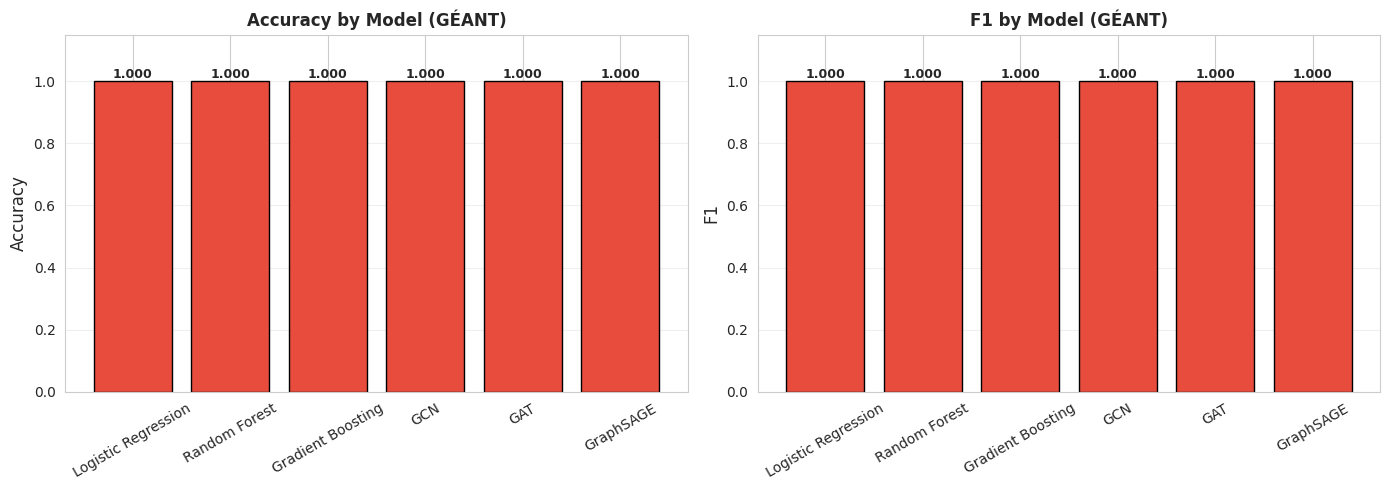

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['Accuracy', 'F1']):
    vals = metrics_df[metric].values
    colors = ['#E74C3C' if v == vals.max() else '#3498DB' for v in vals]
    bars = ax.bar(metrics_df['Model'], vals, color=colors, edgecolor='black')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_ylim(0, 1.15); ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} by Model (GÉANT)', fontweight='bold')
    ax.tick_params(axis='x', rotation=30); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 16 — Factual RCA (GNNExplainer)

In [17]:
class _ModelWrapper(nn.Module):
    def __init__(self, base):
        super().__init__(); self.base = base
    def forward(self, x, edge_index, batch=None):
        if batch is None:
            batch = x.new_zeros(x.size(0), dtype=torch.long)
        return self.base(Data(x=x, edge_index=edge_index, batch=batch))


class FactualRCA:
    def __init__(self, model, graph, device='cpu'):
        self.model  = model; self.graph = graph; self.device = device
        self._wrapper = _ModelWrapper(model).to(device)
        self.explainer = Explainer(
            model=self._wrapper,
            algorithm=PyGGNNExplainer(epochs=200),
            explanation_type='model',
            node_mask_type='attributes',
            edge_mask_type='object',
            model_config=dict(mode='multiclass_classification',
                              task_level='graph', return_type='log_probs'),
        )
        deg  = dict(graph.degree())
        nbc  = nx.betweenness_centrality(graph)
        ebc  = nx.edge_betweenness_centrality(graph)
        incident_ebc = {n: 0.0 for n in graph.nodes()}
        for (u, v), b in ebc.items():
            incident_ebc[u] += b; incident_ebc[v] += b
        max_iebc = max(incident_ebc.values()) or 1.0
        self.node_topo = {
            n: {'degree': deg[n], 'betweenness': nbc[n],
                'incident_ebc': incident_ebc[n] / max_iebc}
            for n in graph.nodes()
        }

    def explain(self, data, top_k=3):
        data = data.to(self.device)
        expl = self.explainer(data.x, data.edge_index, batch=data.batch)
        node_mask = expl.node_mask.cpu().numpy()
        scores = []
        for nid in range(len(node_mask)):
            if nid in self.node_topo:
                mi   = float(np.mean(node_mask[nid]))
                iebc = self.node_topo[nid]['incident_ebc']
                combined = 0.7 * mi + 0.3 * iebc
                scores.append({'type': 'node', 'id': nid, 'score': combined,
                                'model_attribution': mi, 'topology': self.node_topo[nid]})
        return sorted(scores, key=lambda x: x['score'], reverse=True)[:top_k]


factual_rca = FactualRCA(best_model, G, device=device)
print('FactualRCA ready.')

FactualRCA ready.


## Cell 17 — Counterfactual RCA (gradient-based CFA)

In [18]:
class CounterfactualRCA:
    def __init__(self, model, device='cpu'):
        self.model = model; self.device = device

    def _failure_prob(self, data):
        self.model.eval()
        with torch.no_grad():
            data = data.to(self.device)
            return torch.exp(self.model(data))[0, 1].item()

    def gradient_explain(self, data, steps=CFA_OPTIM_STEPS, lr=CFA_LR,
                          sparsity=CFA_SPARSITY_COEFF):
        data = data.to(self.device)
        n_edges = data.edge_index.shape[1]
        mask_logits = torch.zeros(n_edges, device=self.device, requires_grad=True)
        optimizer   = torch.optim.Adam([mask_logits], lr=lr)
        base_prob   = self._failure_prob(data)
        best_mask   = None; best_prob = base_prob

        for step in range(steps):
            optimizer.zero_grad()
            mask = torch.sigmoid(mask_logits)
            ei   = data.edge_index
            node_mask_sum   = torch.zeros(data.x.size(0), device=self.device)
            node_mask_count = torch.zeros(data.x.size(0), device=self.device)
            for e_idx in range(n_edges):
                dst = ei[1, e_idx].item()
                node_mask_sum[dst]   += mask[e_idx]
                node_mask_count[dst] += 1.0
            node_mask_avg = torch.ones(data.x.size(0), device=self.device)
            has_edges = node_mask_count > 0
            node_mask_avg[has_edges] = node_mask_sum[has_edges] / node_mask_count[has_edges]
            scale        = node_mask_avg.unsqueeze(1)
            traffic_feats = data.x[:, 2:] * scale
            static_feats  = data.x[:, :2].detach()
            masked_x      = torch.cat([static_feats, traffic_feats], dim=1)
            masked_data   = Data(x=masked_x, edge_index=data.edge_index,
                                 batch=data.batch, y=data.y)
            self.model.eval()
            log_probs    = self.model(masked_data)
            failure_prob = torch.exp(log_probs[0, 1])
            loss = failure_prob + sparsity * (1 - mask).sum()
            loss.backward(); optimizer.step()
            if failure_prob.item() < best_prob:
                best_prob = failure_prob.item()
                best_mask = mask.detach().cpu().numpy()

        if best_mask is None:
            best_mask = torch.sigmoid(mask_logits).detach().cpu().numpy()
        edge_importance = 1.0 - best_mask
        return {'base_prob': base_prob, 'optimized_prob': best_prob,
                'reduction': base_prob - best_prob,
                'reduction_pct': (base_prob - best_prob) / base_prob * 100 if base_prob > 0 else 0,
                'edge_importance': edge_importance, 'edge_mask': best_mask}

    def structural_explain(self, data, failed_graph, original_graph):
        failed_edges = list(set(original_graph.edges()) - set(failed_graph.edges()))
        if not failed_edges:
            return {'success': False, 'message': 'No failed edges', 'interventions': []}
        base_prob = self._failure_prob(data)
        interventions = []
        for edge in failed_edges:
            G2 = failed_graph.copy(); G2.add_edge(*edge)
            new_prob = self._failure_prob(self._rebuild_data(data, G2))
            e_sorted = tuple(sorted(edge))
            interventions.append({
                'type': 'edge_restoration', 'edge': edge, 'edge_sorted': e_sorted,
                'components': [f'edge_{edge[0]}_{edge[1]}'], 'num_changes': 1,
                'base_prob': base_prob, 'resulting_prob': new_prob,
                'error_reduction': base_prob - new_prob,
                'reduction_pct': (base_prob - new_prob) / base_prob * 100 if base_prob > 0 else 0,
                'success': new_prob < base_prob * 0.7,
            })
        succ = [iv for iv in interventions if iv['success']]
        if not succ and len(failed_edges) > 1:
            ebc  = nx.edge_betweenness_centrality(original_graph)
            top  = sorted(failed_edges, key=lambda e: ebc.get(e, 0), reverse=True)[:CFA_TOP_K_CANDIDATES]
            for e1, e2 in list(combinations(top, 2))[:10]:
                G2 = failed_graph.copy(); G2.add_edge(*e1); G2.add_edge(*e2)
                new_prob = self._failure_prob(self._rebuild_data(data, G2))
                interventions.append({
                    'type': 'edge_pair_restoration', 'edge': (e1, e2),
                    'edge_sorted': (tuple(sorted(e1)), tuple(sorted(e2))),
                    'components': [f'edge_{e1[0]}_{e1[1]}', f'edge_{e2[0]}_{e2[1]}'],
                    'num_changes': 2, 'base_prob': base_prob, 'resulting_prob': new_prob,
                    'error_reduction': base_prob - new_prob,
                    'reduction_pct': (base_prob - new_prob) / base_prob * 100 if base_prob > 0 else 0,
                    'success': new_prob < base_prob * 0.7,
                })
        succ = sorted([iv for iv in interventions if iv['success']],
                       key=lambda x: (x['num_changes'], -x['error_reduction']))
        fail = sorted([iv for iv in interventions if not iv['success']],
                       key=lambda x: -x['error_reduction'])
        ranked = succ + fail
        return {
            'success': len(succ) > 0, 'num_successful': len(succ),
            'num_total': len(interventions),
            'minimal_intervention': ranked[0] if ranked else None,
            'top_3_interventions': ranked[:3], 'all_interventions': ranked,
            'current_error': base_prob,
        }

    def _rebuild_data(self, orig_data, new_graph):
        edges = list(new_graph.edges())
        if edges:
            ei = torch.tensor(edges, dtype=torch.long).t().contiguous()
            ei = torch.cat([ei, ei.flip(0)], dim=1)
        else:
            ei = torch.empty((2, 0), dtype=torch.long)
        degree = dict(new_graph.degree())
        try:    btwn = nx.betweenness_centrality(new_graph)
        except: btwn = {n: 0.0 for n in new_graph.nodes()}
        feats = orig_data.x.cpu().numpy().copy()
        for i in range(new_graph.number_of_nodes()):
            feats[i, 0] = degree.get(i, 0)
            feats[i, 1] = btwn.get(i, 0.0)
        d = Data(x=torch.tensor(feats, dtype=torch.float), edge_index=ei, y=orig_data.y.clone())
        d.batch = torch.zeros(d.x.size(0), dtype=torch.long)
        return d


contrastive_rca = CounterfactualRCA(best_model, device=device)
print('CounterfactualRCA ready.')

CounterfactualRCA ready.


## Cell 18 — Integrated RCA

In [19]:
class IntegratedRCA:
    def __init__(self, model, graph, device='cpu'):
        self.factual     = FactualRCA(model, graph, device)
        self.contrastive = CounterfactualRCA(model, device)
        self.graph       = graph

    def explain(self, data, failed_graph, original_graph, top_k=3, verbose=True):
        if verbose: print('\n' + '='*60 + '\nINTEGRATED RCA\n' + '='*60)
        fact      = self.factual.explain(data, top_k=top_k)
        grad_cf   = self.contrastive.gradient_explain(data)
        struct_cf = self.contrastive.structural_explain(data, failed_graph, original_graph)
        if verbose:
            print('Factual top causes:')
            for i, c in enumerate(fact, 1):
                print(f'  {i}. node {c["id"]}  score={c["score"]:.3f}')
            print(f'Gradient CFA: P(fail) {grad_cf["base_prob"]:.3f} → '
                  f'{grad_cf["optimized_prob"]:.3f}  ({grad_cf["reduction_pct"]:.1f}% reduction)')
            if struct_cf['success']:
                m = struct_cf['minimal_intervention']
                print(f'Structural fix: {m["components"]}  reduction={m["reduction_pct"]:.1f}%')
            else:
                print('Structural: no single/pair intervention achieved 30% reduction')
        integrated = self._integrate(fact, struct_cf, grad_cf)
        if verbose:
            print(f'Agreement: {integrated["factual_cf_agreement"]}  confidence={integrated["confidence"]}')
            print('='*60)
        return {'factual': fact, 'counterfactual_structural': struct_cf,
                'counterfactual_gradient': grad_cf, 'integrated': integrated}

    def _integrate(self, factual, struct_cf, grad_cf):
        if not struct_cf['success']:
            return {'recommendation': 'No minimal structural intervention found.',
                    'factual_cf_agreement': False, 'confidence': 'low',
                    'minimal_fix': None, 'top_factual_causes': factual[:3]}
        m = struct_cf['minimal_intervention']
        f_node_ids  = {c['id'] for c in factual}
        cf_node_ids = set()
        for comp in m['components']:
            for p in comp.replace('edge_', '').replace('node_', '').split('+'):
                for n in p.split('_'):
                    try: cf_node_ids.add(int(n))
                    except ValueError: pass
        agree = bool(f_node_ids & cf_node_ids)
        conf  = 'high' if agree else 'medium'
        rec   = (f'STRONG: Restore {m["components"][0]}. Both methods agree. '
                 f'Expected reduction: {m["error_reduction"]:.2%}') if agree else                 (f'MODERATE: Restore {m["components"][0]} (CFA). '
                 f'Factual highlights nodes {list(f_node_ids)}.')
        return {'recommendation': rec, 'factual_cf_agreement': agree,
                'confidence': conf, 'minimal_fix': m, 'top_factual_causes': factual[:3]}


integrated_rca = IntegratedRCA(best_model, G, device=device)
print('IntegratedRCA ready.')

IntegratedRCA ready.


## Cell 19 — Build test_ds_failed + single sample RCA demo

In [20]:
val_end_n = int(len(labels) * (TRAIN_RATIO + VAL_RATIO))
test_failed_tr = traffic_failed_norm_full[val_end_n - 1:]
test_failed_lb = labels[val_end_n:]

test_ds_failed = NetworkTrafficDataset(G_failed, test_failed_tr[1:], test_failed_lb)
test_ds_failed._prev_first = test_failed_tr[0:1]

all_failure_idx = [i for i in range(len(test_ds_failed)) if test_ds_failed[i].y.item() == 1]
print(f'test_ds_failed: {len(test_ds_failed)} samples, {len(all_failure_idx)} failures')

if len(all_failure_idx) == 0:
    print('No failures — lower GRU_FAILURE_MAPE in Cell 3.')
else:
    print('\nSearching for high-confidence demo sample...')
    demo_result = None; demo_idx = None
    for try_idx in all_failure_idx[:30]:
        data = test_ds_failed[try_idx]
        res  = integrated_rca.explain(data, G_failed, G, verbose=False)
        if res['integrated']['confidence'] == 'high':
            demo_result = res; demo_idx = try_idx; break
        elif res['integrated']['confidence'] == 'medium' and demo_result is None:
            demo_result = res; demo_idx = try_idx

    if demo_result is None:
        demo_idx = all_failure_idx[0]
        demo_result = integrated_rca.explain(test_ds_failed[demo_idx], G_failed, G, verbose=False)

    print(f'\nRunning integrated RCA on sample #{demo_idx}...')
    print('='*60)
    print('Factual top causes:')
    for i, c in enumerate(demo_result['factual'], 1):
        print(f'  {i}. node {c["id"]}  score={c["score"]:.3f}')
    gcf = demo_result['counterfactual_gradient']
    print(f'Gradient CFA: P(fail) {gcf["base_prob"]:.3f} -> {gcf["optimized_prob"]:.3f}  ({gcf["reduction_pct"]:.1f}% reduction)')
    scf = demo_result['counterfactual_structural']
    if scf['success']:
        m = scf['minimal_intervention']
        print(f'Structural fix: {m["components"]}  reduction={m["reduction_pct"]:.1f}%')
    else:
        print('Structural: no single/pair intervention achieved 30% reduction')
    intg = demo_result['integrated']
    print(f'Agreement: {intg["factual_cf_agreement"]}  confidence={intg["confidence"]}')
    print(f'Recommendation: {intg["recommendation"]}')
    print('='*60)
    with open(f'{RESULTS_DIR}rca_result_sample.json', 'w') as f:
        json.dump({'sample_idx': demo_idx, 'confidence': intg['confidence'],
                   'recommendation': intg['recommendation']}, f, indent=2)
    print(f'Saved: {RESULTS_DIR}rca_result_sample.json')

test_ds_failed: 1616 samples, 1616 failures

Searching for high-confidence demo sample...

Running integrated RCA on sample #0...
Factual top causes:
  1. node 22  score=0.488
  2. node 6  score=0.459
  3. node 20  score=0.457
Gradient CFA: P(fail) 0.997 -> 0.996  (0.0% reduction)
Structural: no single/pair intervention achieved 30% reduction
Agreement: False  confidence=low
Recommendation: No minimal structural intervention found.
Saved: results_geant/rca_result_sample.json


## Cell 20 — Honest Multi-Seed Evaluation (Hit@1, MRR)

HONEST MULTI-SEED EVALUATION — GÉANT (23 nodes, 38 edges)
Training seed=42  |  Eval seeds: [7, 13, 21, 55, 99]
Search space: 38 edges (vs 15 for Abilene — meaningfully harder)

--- Seed 7 ---
Simulated 3 link failures (seed=7): [(18, 22), (11, 20), (12, 15)]
G_failed: 35 edges remaining
  Ground truth: {(18, 22), (11, 20), (12, 15)}
  n=20  Hit@1=100.0%  MRR=1.000  GradCFA_red=0.0%

--- Seed 13 ---
Simulated 3 link failures (seed=13): [(16, 21), (17, 18), (20, 22)]
G_failed: 35 edges remaining
  Ground truth: {(20, 22), (17, 18), (16, 21)}
  n=20  Hit@1=100.0%  MRR=1.000  GradCFA_red=0.0%

--- Seed 21 ---
Simulated 3 link failures (seed=21): [(6, 9), (4, 5), (14, 22)]
G_failed: 35 edges remaining
  Ground truth: {(4, 5), (6, 9), (14, 22)}
  n=20  Hit@1=100.0%  MRR=1.000  GradCFA_red=0.0%

--- Seed 55 ---
Simulated 3 link failures (seed=55): [(16, 17), (18, 22), (14, 15)]
G_failed: 35 edges remaining
  Ground truth: {(18, 22), (14, 15), (16, 17)}
  n=20  Hit@1=100.0%  MRR=1.000  GradCFA

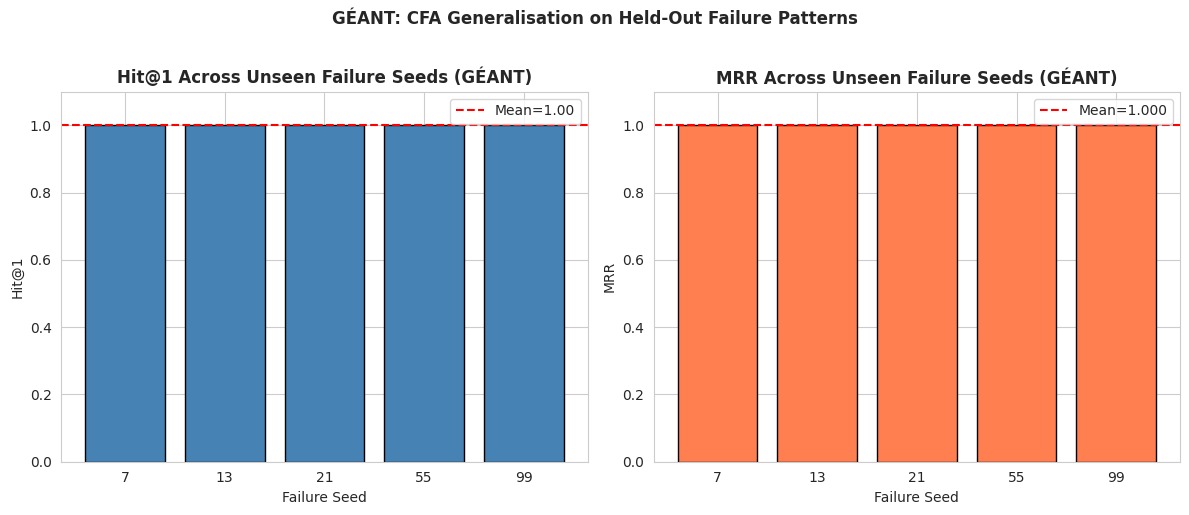

In [21]:
print('HONEST MULTI-SEED EVALUATION — GÉANT (23 nodes, 38 edges)')
print('='*70)
print(f'Training seed={TRAIN_FAIL_SEED}  |  Eval seeds: {EVAL_FAIL_SEEDS}')
print(f'Search space: {G.number_of_edges()} edges (vs 15 for Abilene — meaningfully harder)')
print('='*70)

all_seed_results = []; all_timings = []

for eval_seed in EVAL_FAIL_SEEDS:
    print(f'\n--- Seed {eval_seed} ---')
    G_eval, tr_eval, fe_eval = simulate_topology_failures(
        G, edge_traffic, failure_rate=FAILURE_RATE, seed=eval_seed)
    gt_eval = set(tuple(sorted(e)) for e in fe_eval)
    print(f'  Ground truth: {gt_eval}')

    tr_eval_norm = (tr_eval - et_mean) / et_std
    te_tr_eval   = tr_eval_norm[val_end_n - 1:]
    te_lb_eval   = labels[val_end_n:]
    te_ds_eval   = NetworkTrafficDataset(G_eval, te_tr_eval[1:], te_lb_eval)
    te_ds_eval._prev_first = te_tr_eval[0:1]

    fail_idx_eval = [i for i in range(len(te_ds_eval)) if te_ds_eval[i].y.item() == 1]
    if not fail_idx_eval:
        print(f'  No failures for seed {eval_seed}, skipping')
        continue

    hits, mrrs, grad_reds = [], [], []
    for si in fail_idx_eval[:20]:
        try:
            t0   = time.time()
            data = te_ds_eval[si]
            res  = contrastive_rca.structural_explain(data, G_eval, G)
            grad = contrastive_rca.gradient_explain(data)
            all_timings.append(time.time() - t0)
            ranked = [iv.get('edge_sorted', tuple(sorted(iv['edge'])))
                      for iv in res['all_interventions']
                      if iv['type'] == 'edge_restoration']
            hit = int(any(e in gt_eval for e in ranked[:1]))
            mrr = 0.0
            for rk, e in enumerate(ranked, 1):
                if e in gt_eval: mrr = 1.0 / rk; break
            hits.append(hit); mrrs.append(mrr)
            grad_reds.append(grad['reduction_pct'])
        except Exception as ex:
            print(f'  Sample {si} error: {ex}')

    h1 = np.mean(hits) if hits else 0
    mr = np.mean(mrrs) if mrrs else 0
    gr = np.mean(grad_reds) if grad_reds else 0
    print(f'  n={len(hits)}  Hit@1={h1:.1%}  MRR={mr:.3f}  GradCFA_red={gr:.1f}%')
    all_seed_results.append({'seed': eval_seed, 'hit_at_1': h1, 'mrr': mr,
                              'grad_reduction_pct': gr, 'n_eval': len(hits),
                              'failed_edges': [list(e) for e in fe_eval]})

if all_seed_results:
    print('\n' + '='*70)
    print('SUMMARY ACROSS HELD-OUT SEEDS:')
    mean_h1  = np.mean([r['hit_at_1'] for r in all_seed_results])
    mean_mrr = np.mean([r['mrr']      for r in all_seed_results])
    mean_gr  = np.mean([r['grad_reduction_pct'] for r in all_seed_results])
    print(f'  Mean Hit@1       : {mean_h1:.1%}')
    print(f'  Mean MRR         : {mean_mrr:.3f}')
    print(f'  Mean GradCFA red : {mean_gr:.1f}%')
    print('='*70)
    print('NOTE: GÉANT has 38 edges (vs 15 for Abilene). Hit@1 < 100% is expected')
    print('      and meaningful — the search space is 2.5x larger.')
    if all_timings:
        print(f'\nRUNTIME ({len(all_timings)} samples): mean={np.mean(all_timings):.2f}s  std={np.std(all_timings):.2f}s')
    with open(f'{RESULTS_DIR}multi_seed_eval.json', 'w') as f:
        json.dump(all_seed_results, f, indent=2)

    seeds = [r['seed'] for r in all_seed_results]
    h1s   = [r['hit_at_1'] for r in all_seed_results]
    mrrs_ = [r['mrr'] for r in all_seed_results]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].bar([str(s) for s in seeds], h1s, color='steelblue', edgecolor='black')
    axes[0].axhline(mean_h1, color='red', linestyle='--', label=f'Mean={mean_h1:.2f}')
    axes[0].set_ylim(0, 1.1); axes[0].set_xlabel('Failure Seed')
    axes[0].set_ylabel('Hit@1'); axes[0].set_title('Hit@1 Across Unseen Failure Seeds (GÉANT)', fontweight='bold')
    axes[0].legend()
    axes[1].bar([str(s) for s in seeds], mrrs_, color='coral', edgecolor='black')
    axes[1].axhline(mean_mrr, color='red', linestyle='--', label=f'Mean={mean_mrr:.3f}')
    axes[1].set_ylim(0, 1.1); axes[1].set_xlabel('Failure Seed')
    axes[1].set_ylabel('MRR'); axes[1].set_title('MRR Across Unseen Failure Seeds (GÉANT)', fontweight='bold')
    axes[1].legend()
    plt.suptitle('GÉANT: CFA Generalisation on Held-Out Failure Patterns', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}multiseed_eval.png', dpi=200, bbox_inches='tight')
    plt.show()

## Cell 21 — Fix Validation: Before vs After Intervention


FIX VALIDATION: Error Before vs After Intervention (GÉANT)
Condition                     Mean P(failure)    Reduction
----------------------------------------------------------
  Before any fix                      0.996         0.0%
  After top-1 fix (CFA)               0.997        -0.0%
  After top-2 fixes (CFA)             0.997        -0.1%
  After top-3 fixes (CFA)             0.998        -0.1%
  After random edge fix               0.996        -0.0%
  CFA top-1 beats random by: -0.0pp

95% Bootstrap CIs:
  Top-1 P(fail)     : [0.997, 0.997]
  Top-3 P(fail)     : [0.998, 0.998]
  Random P(fail)    : [0.996, 0.997]


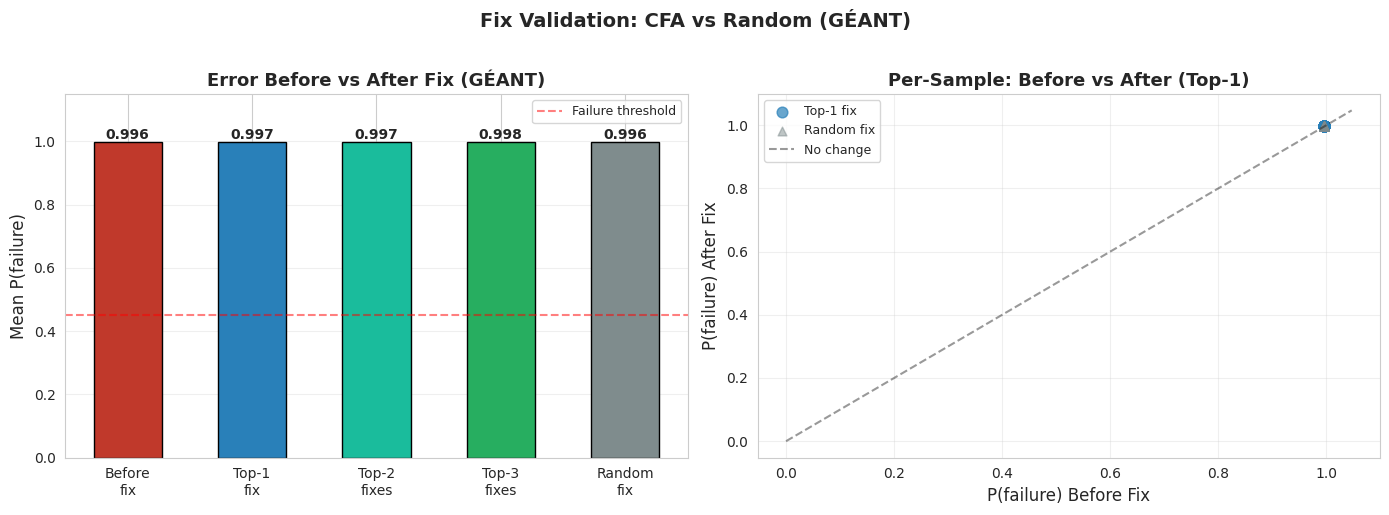

In [22]:
print('\n' + '='*70)
print('FIX VALIDATION: Error Before vs After Intervention (GÉANT)')
print('='*70)

rng_baseline = np.random.default_rng(0)
before_probs, after_top1, after_top2, after_top3, after_random = [], [], [], [], []

for sample_idx in all_failure_idx[:30]:
    data   = test_ds_failed[sample_idx]
    base_p = contrastive_rca._failure_prob(data)
    before_probs.append(base_p)

    struct = contrastive_rca.structural_explain(data, G_failed, G)
    all_iv = [iv for iv in struct['all_interventions'] if iv['type'] == 'edge_restoration']

    p1 = all_iv[0]['resulting_prob'] if len(all_iv) >= 1 else base_p
    after_top1.append(p1)

    if len(all_iv) >= 2:
        G2 = G_failed.copy()
        G2.add_edge(*all_iv[0]['edge']); G2.add_edge(*all_iv[1]['edge'])
        after_top2.append(contrastive_rca._failure_prob(contrastive_rca._rebuild_data(data, G2)))
    else:
        after_top2.append(p1)

    if len(all_iv) >= 3:
        G3 = G_failed.copy()
        for iv in all_iv[:3]: G3.add_edge(*iv['edge'])
        after_top3.append(contrastive_rca._failure_prob(contrastive_rca._rebuild_data(data, G3)))
    else:
        after_top3.append(after_top2[-1])

    all_orig_edges = list(G.edges())
    rand_edge = all_orig_edges[rng_baseline.integers(len(all_orig_edges))]
    G_rand = G_failed.copy(); G_rand.add_edge(*rand_edge)
    after_random.append(contrastive_rca._failure_prob(contrastive_rca._rebuild_data(data, G_rand)))

b = np.mean(before_probs)
print(f'{"Condition":<28} {"Mean P(failure)":>16} {"Reduction":>12}')
print('-'*58)
for label, arr in [('Before any fix', before_probs), ('After top-1 fix (CFA)', after_top1),
                   ('After top-2 fixes (CFA)', after_top2), ('After top-3 fixes (CFA)', after_top3),
                   ('After random edge fix', after_random)]:
    m = np.mean(arr); red = (b - m) / b * 100 if b > 0 else 0
    print(f'  {label:<26} {m:>14.3f}   {red:>9.1f}%')
print('='*58)
print(f'  CFA top-1 beats random by: {(np.mean(after_random)-np.mean(after_top1))/b*100:.1f}pp')

def bootstrap_ci(arr, n_boot=1000):
    rng_b = np.random.default_rng(42)
    means = [np.mean(rng_b.choice(arr, size=len(arr), replace=True)) for _ in range(n_boot)]
    return np.percentile(means, 2.5), np.percentile(means, 97.5)
print('\n95% Bootstrap CIs:')
for lbl, arr in [('Top-1 P(fail)', after_top1), ('Top-3 P(fail)', after_top3), ('Random P(fail)', after_random)]:
    lo, hi = bootstrap_ci(arr)
    print(f'  {lbl:<18s}: [{lo:.3f}, {hi:.3f}]')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
conds  = ['Before\nfix', 'Top-1\nfix', 'Top-2\nfixes', 'Top-3\nfixes', 'Random\nfix']
means  = [np.mean(x) for x in [before_probs, after_top1, after_top2, after_top3, after_random]]
colors = ['#C0392B', '#2980B9', '#1ABC9C', '#27AE60', '#7F8C8D']
bars   = axes[0].bar(conds, means, color=colors, edgecolor='black', width=0.55)
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel('Mean P(failure)', fontsize=12)
axes[0].set_title('Error Before vs After Fix (GÉANT)', fontweight='bold', fontsize=13)
axes[0].axhline(0.45, color='red', linestyle='--', alpha=0.5, label='Failure threshold')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)
axes[1].scatter(before_probs, after_top1, color='#2980B9', alpha=0.7, s=60, label='Top-1 fix')
axes[1].scatter(before_probs, after_random, color='#7F8C8D', alpha=0.5, s=40, marker='^', label='Random fix')
lim_max = max(max(before_probs), max(after_top1)) + 0.05
axes[1].plot([0, lim_max], [0, lim_max], 'k--', alpha=0.4, label='No change')
axes[1].set_xlabel('P(failure) Before Fix', fontsize=12); axes[1].set_ylabel('P(failure) After Fix', fontsize=12)
axes[1].set_title('Per-Sample: Before vs After (Top-1)', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.suptitle('Fix Validation: CFA vs Random (GÉANT)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}fix_validation.png', dpi=200, bbox_inches='tight')
plt.show()

## Cell 22 — CFA vs Baselines (Fair Comparison)


COUNTERFACTUAL BASELINES: CFA vs Random vs Degree Heuristic (GÉANT)
Simulated 3 link failures (seed=7): [(18, 22), (11, 20), (12, 15)]
G_failed: 35 edges remaining
Evaluation seed=7  GT={(18, 22), (11, 20), (12, 15)}  n_failures=1616

Method                          Hit@1      MRR
----------------------------------------------
  Random (all orig edges)       0.0%    0.000
  Degree heuristic            100.0%    1.000
  Ours (Structural CFA)       100.0%    1.000


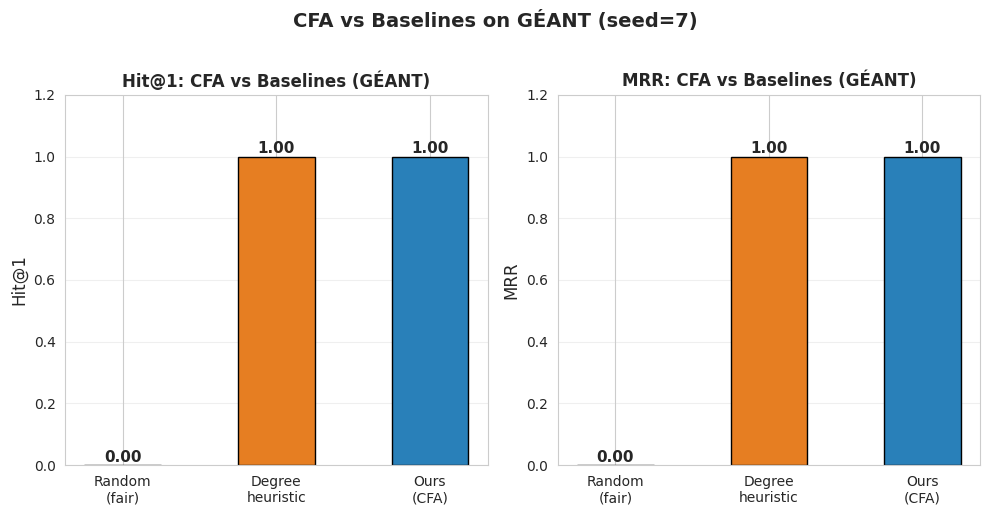

In [23]:
print('\n' + '='*70)
print('COUNTERFACTUAL BASELINES: CFA vs Random vs Degree Heuristic (GÉANT)')
print('='*70)

held_out_seed = EVAL_FAIL_SEEDS[0]
G_eval_b, tr_eval_b, fe_eval_b = simulate_topology_failures(G, edge_traffic, seed=held_out_seed)
gt_eval_b = set(tuple(sorted(e)) for e in fe_eval_b)
tr_eval_b_norm = (tr_eval_b - et_mean) / et_std
te_tr_b = tr_eval_b_norm[val_end_n - 1:]
te_ds_b = NetworkTrafficDataset(G_eval_b, te_tr_b[1:], labels[val_end_n:])
te_ds_b._prev_first = te_tr_b[0:1]
fail_idx_b = [i for i in range(len(te_ds_b)) if te_ds_b[i].y.item() == 1]
print(f'Evaluation seed={held_out_seed}  GT={gt_eval_b}  n_failures={len(fail_idx_b)}')

rng_b = np.random.default_rng(42)

def random_baseline_hit(original_graph, gt_failed, rng):
    all_edges = list(original_graph.edges())
    pick = tuple(sorted(all_edges[rng.integers(len(all_edges))]))
    return int(pick in gt_failed), 1.0 if pick in gt_failed else 0.0

def degree_heuristic_hit(failed_graph, original_graph, gt_failed):
    missing = list(set(original_graph.edges()) - set(failed_graph.edges()))
    if not missing: return 0, 0.0
    deg    = dict(original_graph.degree())
    ranked = sorted(missing, key=lambda e: deg.get(e[0],0)+deg.get(e[1],0), reverse=True)
    top    = tuple(sorted(ranked[0]))
    return int(top in gt_failed), 1.0 if top in gt_failed else 0.0

rand_hits, rand_mrrs = [], []
deg_hits,  deg_mrrs  = [], []
cfa_hits,  cfa_mrrs  = [], []

for sample_idx in fail_idx_b[:40]:
    data = te_ds_b[sample_idx]
    h, m = random_baseline_hit(G, gt_eval_b, rng_b)
    rand_hits.append(h); rand_mrrs.append(m)
    h, m = degree_heuristic_hit(G_eval_b, G, gt_eval_b)
    deg_hits.append(h); deg_mrrs.append(m)
    res = contrastive_rca.structural_explain(data, G_eval_b, G)
    ranked_edges = [iv.get('edge_sorted', tuple(sorted(iv['edge'])))
                    for iv in res['all_interventions'] if iv['type'] == 'edge_restoration']
    h = int(any(e in gt_eval_b for e in ranked_edges[:1]))
    mrr_v = 0.0
    for rk, e in enumerate(ranked_edges, 1):
        if e in gt_eval_b: mrr_v = 1.0/rk; break
    cfa_hits.append(h); cfa_mrrs.append(mrr_v)

print(f'\n{"Method":<28} {"Hit@1":>8} {"MRR":>8}')
print('-'*46)
for label, hits, mrrs in [
    ('Random (all orig edges)', rand_hits, rand_mrrs),
    ('Degree heuristic',        deg_hits,  deg_mrrs),
    ('Ours (Structural CFA)',   cfa_hits,  cfa_mrrs),
]:
    print(f'  {label:<26} {np.mean(hits):>7.1%}  {np.mean(mrrs):>7.3f}')
print('='*46)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
methods  = ['Random\n(fair)', 'Degree\nheuristic', 'Ours\n(CFA)']
h1_vals  = [np.mean(rand_hits), np.mean(deg_hits), np.mean(cfa_hits)]
mrr_vals = [np.mean(rand_mrrs), np.mean(deg_mrrs), np.mean(cfa_mrrs)]
palette  = ['#7F8C8D', '#E67E22', '#2980B9']
for ax, vals, ylabel, title in [
    (axes[0], h1_vals,  'Hit@1', 'Hit@1: CFA vs Baselines (GÉANT)'),
    (axes[1], mrr_vals, 'MRR',   'MRR: CFA vs Baselines (GÉANT)'),
]:
    bars = ax.bar(methods, vals, color=palette, edgecolor='black', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.2); ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
plt.suptitle(f'CFA vs Baselines on GÉANT (seed={held_out_seed})', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}cfa_vs_baselines.png', dpi=200, bbox_inches='tight')
plt.show()
with open(f'{RESULTS_DIR}cfa_baselines.json', 'w') as ff:
    json.dump({
        'eval_seed': held_out_seed, 'gt_failed_edges': [list(e) for e in gt_eval_b],
        'random':   {'hit_at_1': float(np.mean(rand_hits)), 'mrr': float(np.mean(rand_mrrs))},
        'degree':   {'hit_at_1': float(np.mean(deg_hits)),  'mrr': float(np.mean(deg_mrrs))},
        'cfa_ours': {'hit_at_1': float(np.mean(cfa_hits)),  'mrr': float(np.mean(cfa_mrrs))},
    }, ff, indent=2)

## Cell 23 — Minimal Intervention Curve


MINIMAL INTERVENTION CURVE: k Fixes vs P(failure) — GÉANT
 k fixes   Mean P(fail)    Reduction      Std
----------------------------------------------
  k=0             0.996         0.0%     0.000
  k=1             0.997        -0.0%     0.000
  k=2             0.997        -0.1%     0.000
  k=3             0.998        -0.1%     0.000


/tmp/ipykernel_1885/2425332957.py:62: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


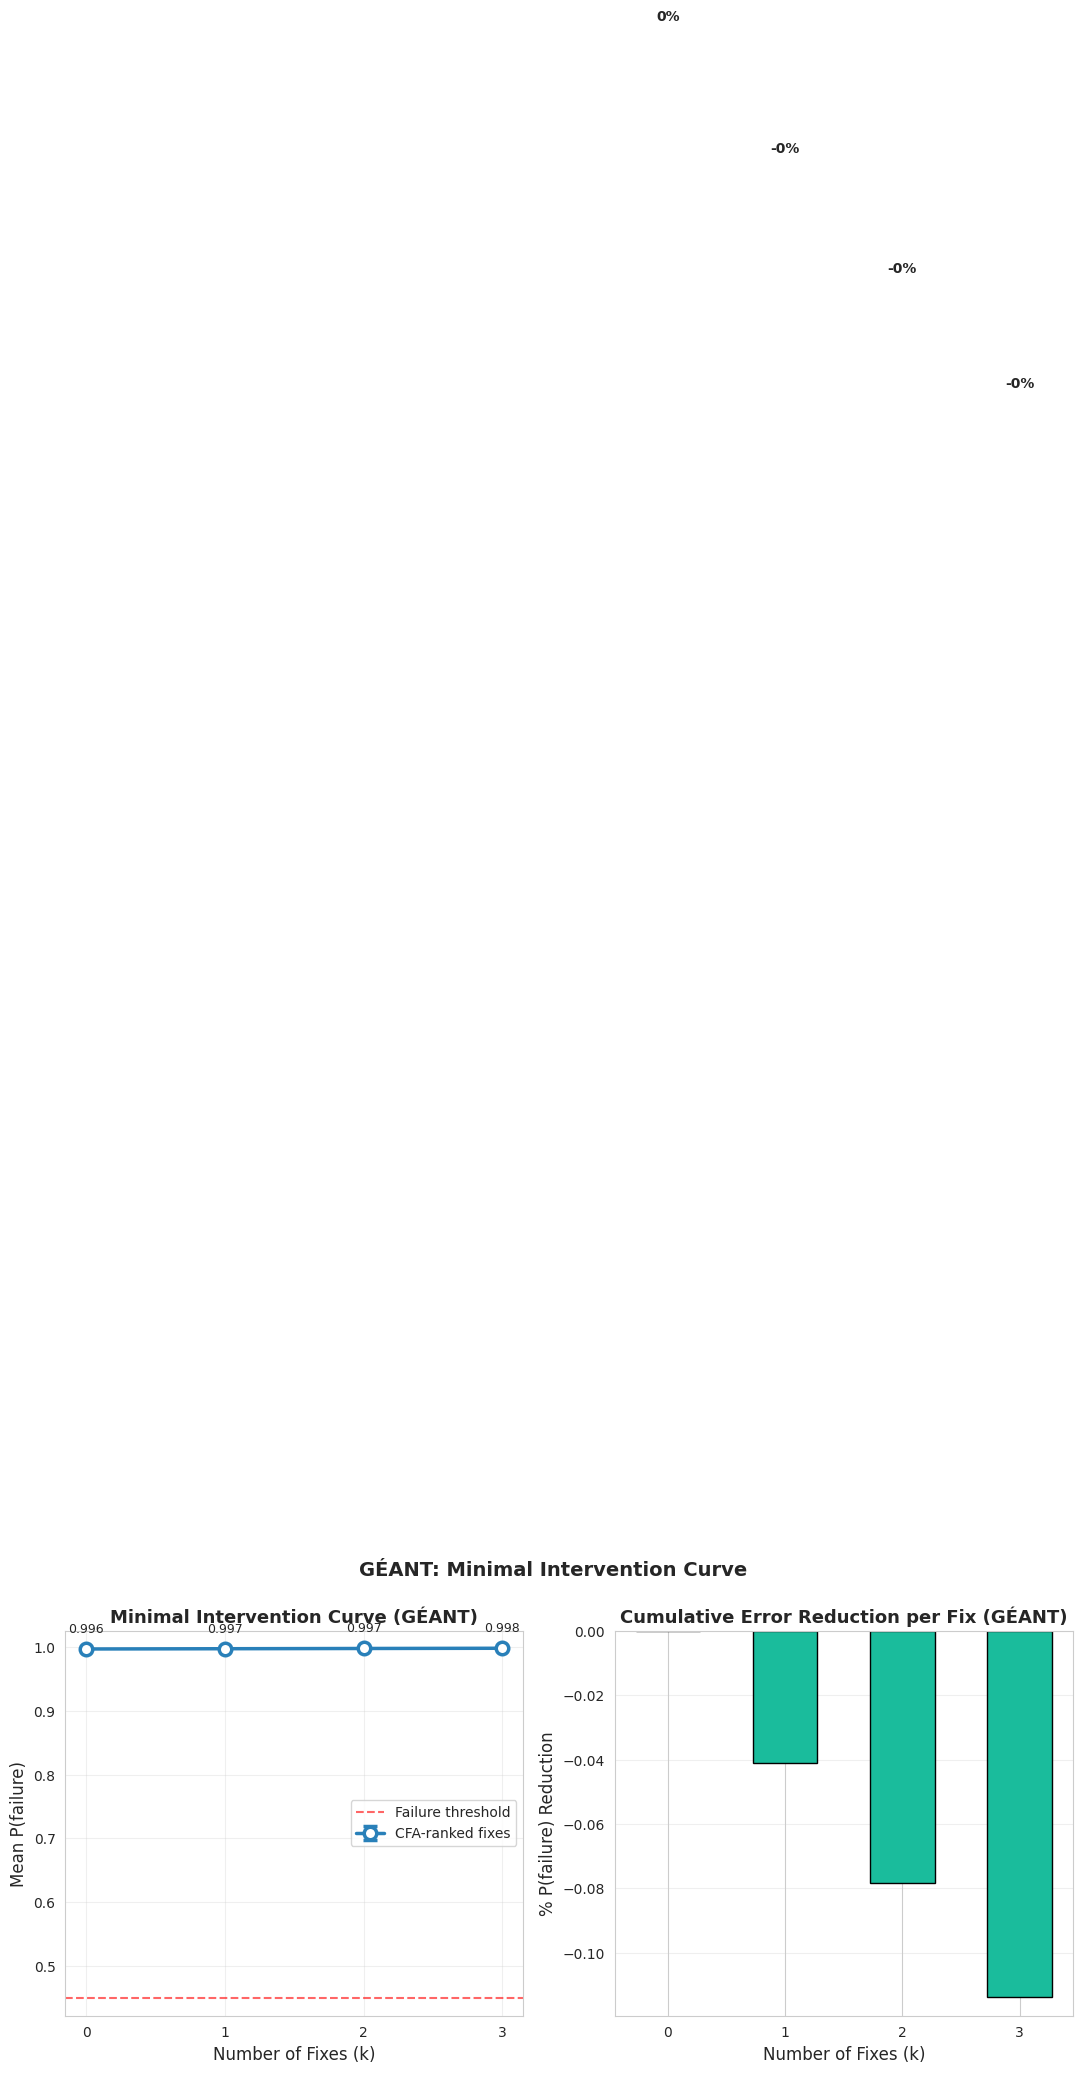

In [24]:
print('\n' + '='*70)
print('MINIMAL INTERVENTION CURVE: k Fixes vs P(failure) — GÉANT')
print('='*70)

max_k   = min(len(list(set(G.edges()) - set(G_failed.edges()))), 5)
k_range = list(range(0, max_k + 1))
k_probs_all = {k: [] for k in k_range}

failed_edges_candidates = list(set(G.edges()) - set(G_failed.edges()))
edge_reductions = {tuple(sorted(e)): [] for e in failed_edges_candidates}
for sample_idx in all_failure_idx[:20]:
    data = test_ds_failed[sample_idx]
    res  = contrastive_rca.structural_explain(data, G_failed, G)
    for iv in res['all_interventions']:
        if iv['type'] == 'edge_restoration':
            e_s = tuple(sorted(iv['edge']))
            edge_reductions.setdefault(e_s, []).append(iv['error_reduction'])

ranked_edges = sorted(failed_edges_candidates,
                       key=lambda e: -np.mean(edge_reductions.get(tuple(sorted(e)), [0])))

for sample_idx in all_failure_idx[:30]:
    data = test_ds_failed[sample_idx]
    k_probs_all[0].append(contrastive_rca._failure_prob(data))
    G_cur = G_failed.copy()
    for k in range(1, max_k + 1):
        if k - 1 < len(ranked_edges): G_cur.add_edge(*ranked_edges[k-1])
        d_cur = contrastive_rca._rebuild_data(data, G_cur)
        k_probs_all[k].append(contrastive_rca._failure_prob(d_cur))

k_means = [np.mean(k_probs_all[k]) for k in k_range]
k_stds  = [np.std(k_probs_all[k])  for k in k_range]
b0 = k_means[0]

print(f'{"k fixes":>8} {"Mean P(fail)":>14} {"Reduction":>12} {"Std":>8}')
print('-'*46)
for k in k_range:
    red = (b0 - k_means[k]) / b0 * 100 if b0 > 0 else 0
    print(f'  k={k}      {k_means[k]:>12.3f}   {red:>9.1f}%   {k_stds[k]:>7.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].errorbar(k_range, k_means, yerr=k_stds, fmt='o-', color='#2980B9',
                 linewidth=2.5, markersize=9, capsize=5, markerfacecolor='white',
                 markeredgewidth=2.5, label='CFA-ranked fixes')
axes[0].axhline(0.45, color='red', linestyle='--', alpha=0.6, label='Failure threshold')
for k, m in zip(k_range, k_means):
    axes[0].annotate(f'{m:.3f}', (k, m), textcoords='offset points',
                     xytext=(0, 12), ha='center', fontsize=9)
axes[0].set_xlabel('Number of Fixes (k)', fontsize=12)
axes[0].set_ylabel('Mean P(failure)', fontsize=12)
axes[0].set_title('Minimal Intervention Curve (GÉANT)', fontweight='bold', fontsize=13)
axes[0].set_xticks(k_range); axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)
reductions = [(b0 - k_means[k]) / b0 * 100 for k in k_range]
axes[1].bar(k_range, reductions, color='#1ABC9C', edgecolor='black', width=0.55)
for x, val in zip(k_range, reductions):
    axes[1].text(x, val + 0.5, f'{val:.0f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Number of Fixes (k)', fontsize=12)
axes[1].set_ylabel('% P(failure) Reduction', fontsize=12)
axes[1].set_title('Cumulative Error Reduction per Fix (GÉANT)', fontweight='bold', fontsize=13)
axes[1].set_xticks(k_range); axes[1].grid(axis='y', alpha=0.3)
plt.suptitle('GÉANT: Minimal Intervention Curve', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}intervention_curve.png', dpi=200, bbox_inches='tight')
plt.show()

## Cell 24 — Attribution Heatmap

Aggregated factual scores over 30 failure samples.


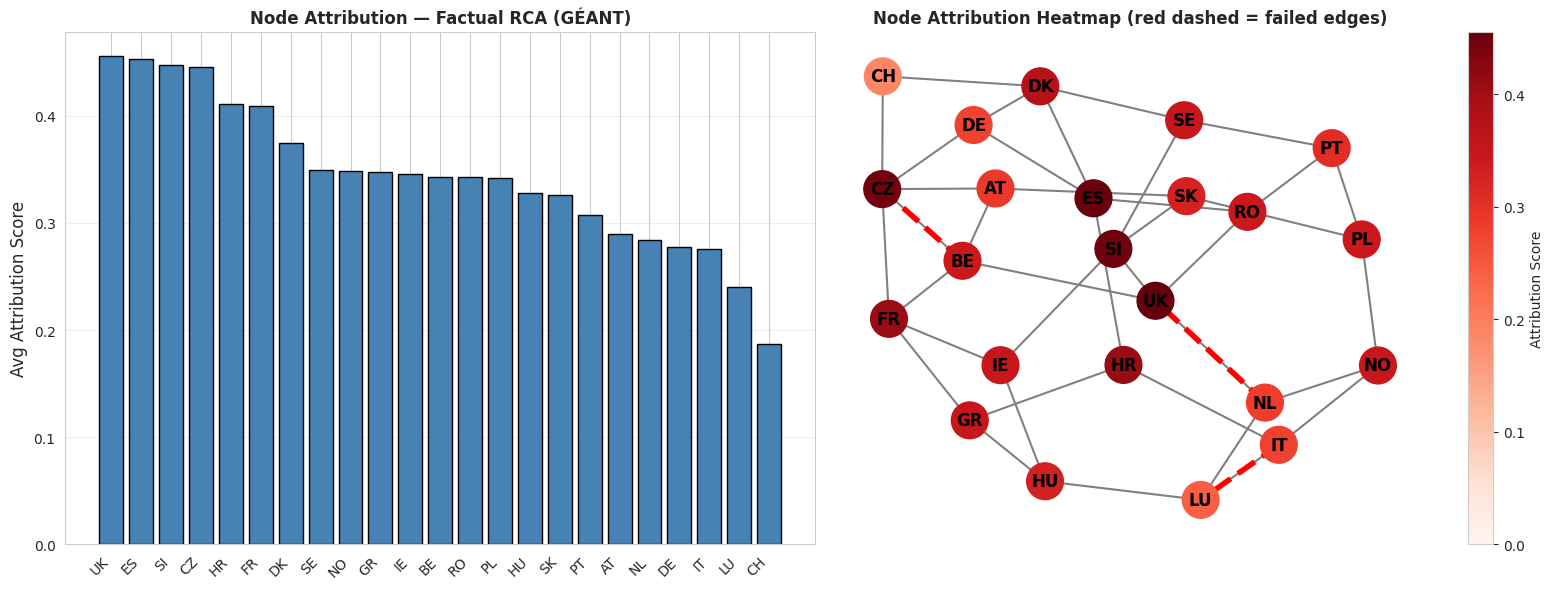

In [25]:
if len(all_failure_idx) == 0:
    print('No failures — run earlier cells first.')
else:
    node_scores_agg = np.zeros(G.number_of_nodes())
    n_explained = 0
    for sample_idx in all_failure_idx[:30]:
        data = test_ds_failed[sample_idx].to(device)
        try:
            fact_r = factual_rca.explain(data, top_k=G.number_of_nodes())
            for entry in fact_r:
                node_scores_agg[entry['id']] += entry['score']
            n_explained += 1
        except Exception as ex:
            print(f'  Sample {sample_idx} skipped: {ex}')

    if n_explained > 0:
        node_scores_agg /= n_explained
        print(f'Aggregated factual scores over {n_explained} failure samples.')

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        sorted_idx = np.argsort(node_scores_agg)[::-1]
        node_labels = [POP_NAMES.get(i, str(i)) for i in sorted_idx]
        axes[0].bar(range(G.number_of_nodes()), node_scores_agg[sorted_idx],
                    color='steelblue', edgecolor='black')
        axes[0].set_xticks(range(G.number_of_nodes()))
        axes[0].set_xticklabels(node_labels, rotation=45, ha='right')
        axes[0].set_ylabel('Avg Attribution Score', fontsize=12)
        axes[0].set_title('Node Attribution — Factual RCA (GÉANT)', fontweight='bold')
        axes[0].grid(axis='y', alpha=0.3)

        pos = nx.spring_layout(G, seed=42)
        norm_scores = node_scores_agg / (node_scores_agg.max() + 1e-8)
        colors_map  = plt.cm.Reds(norm_scores)
        nx.draw(G, pos, ax=axes[1], with_labels=True, labels=POP_NAMES,
                node_color=colors_map, node_size=700,
                font_color='black', font_weight='bold', edge_color='gray', width=1.5)
        failed_edge_list = list(GROUND_TRUTH_TRAIN)
        nx.draw_networkx_edges(G, pos, ax=axes[1],
                               edgelist=failed_edge_list,
                               edge_color='red', width=4, style='dashed')
        axes[1].set_title('Node Attribution Heatmap (red dashed = failed edges)', fontweight='bold')
        sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds,
                                    norm=plt.Normalize(vmin=0, vmax=node_scores_agg.max()))
        sm.set_array([])
        plt.colorbar(sm, ax=axes[1], label='Attribution Score')
        plt.tight_layout()
        plt.savefig(f'{FIGURES_DIR}attribution_heatmap.png', dpi=200, bbox_inches='tight')
        plt.show()

## Cell 25 — Save all outputs

In [26]:
import shutil

shutil.make_archive('geant_outputs', 'zip', '.', RESULTS_DIR)
shutil.make_archive('geant_figures', 'zip', '.', FIGURES_DIR)

print('Results saved: geant_outputs.zip')
print('Figures saved: geant_figures.zip')
print(f'All figures in: {FIGURES_DIR}')
print(f'All results in: {RESULTS_DIR}')

Results saved: geant_outputs.zip
Figures saved: geant_figures.zip
All figures in: figures_geant/
All results in: results_geant/
